## Import Libraries

Importing used Libraries in this cell.

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn

## Preprocessing Dataset 

It takes the path of the dataset, then crop and transform each image(images are combined).

Then using PyTorch DataLoader, the Train and Validation data loaded.

In [ ]:
class PreprocessDataset(Dataset):
    def __init__(self, root):
        self.root = root
        self.images = os.listdir(root)
        self.transform = transforms.Compose([
            transforms.Resize(286),
            transforms.CenterCrop(256),            
            transforms.ToTensor(),                     
            transforms.Normalize((0.5,), (0.5,))
        ])


    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.images[idx])
        img = Image.open(img_path).convert("RGB")
        
        w, h = img.size
        input_image = img.crop((w // 2, 0, w, h))    # Right half: segmented image
        target_image = img.crop((0, 0, w // 2, h))   # Left half: real image

        input_image = self.transform(input_image)
        target_image = self.transform(target_image)

        return input_image, target_image



train_path = "/kaggle/input/cityscapes-pix2pix-dataset/train"
val_path = "/kaggle/input/cityscapes-pix2pix-dataset/val"

batch_size = 1

train_dataset = PreprocessDataset(root=train_path)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
)

val_dataset = PreprocessDataset(root=val_path)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)


## Show images

In this part the 3 images from train and validation dataset are shown.

In [ ]:
def show_images(dataloader, num_images=3):
    fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 3))
    for i, (input_img, target_img) in enumerate(dataloader):
        if i >= num_images:
            break

        input_img = input_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
        target_img = target_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5

        axes[i, 0].imshow(input_img)
        axes[i, 0].set_title("Segmented Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(target_img)
        axes[i, 1].set_title("Real Image")
        axes[i, 1].axis("off")
    
    plt.tight_layout()
    plt.show()

show_images(train_loader)
show_images(val_loader)

## Generator

Like the paper Architecture I implemented the encoder and decoder of Generator with the following scheme:

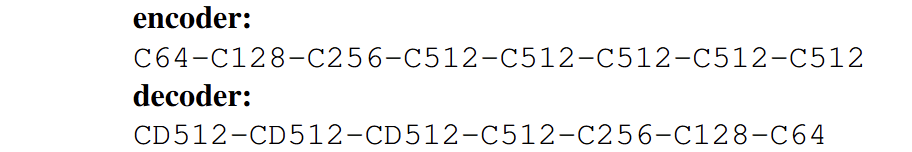

And the U-Net decoder ($d_i$s in def forward):
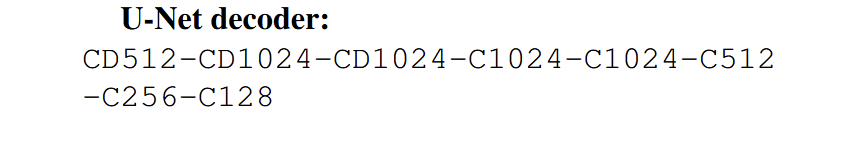

Which Ck denote a Convolution-BatchNorm-ReLU layer with k filters. CDk denotes a Convolution-BatchNormDropout-ReLU layer with a dropout rate of 50%. All convolutions are 4 × 4 spatial filters applied with stride 2. Convolutions in the encoder, and in the discriminator, downsample by a factor of 2, whereas in the decoder they upsample by a factor of 2.

The U-Net architecture is identical except with skip connections between each layer i in the encoder and layer n − i in the decoder, where n is the total number of layers. The
skip connections concatenate activations from layer i to layer n − i.


encoder_block and decoder_block: 
It's just used for the clean code to avoid repeating.

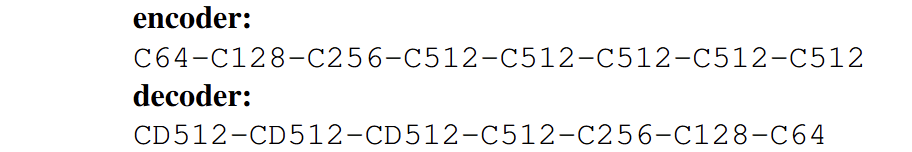

In [ ]:
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, ngf):
        super(Generator, self).__init__()
        
        # Encoder (Downsampling)
        self.enc1 = nn.Conv2d(input_nc, ngf, kernel_size=4, stride=2, padding=1)  # No BatchNorm for first layer
        self.enc2 = self.encoder_block(ngf, ngf * 2)  # (ngf*2)
        self.enc3 = self.encoder_block(ngf * 2, ngf * 4)  # (ngf*4)
        self.enc4 = self.encoder_block(ngf * 4, ngf * 8)  # (ngf*8)
        self.enc5 = self.encoder_block(ngf * 8, ngf * 8)  # (ngf*8)
        self.enc6 = self.encoder_block(ngf * 8, ngf * 8)  # (ngf*8)
        self.enc7 = self.encoder_block(ngf * 8, ngf * 8)  # (ngf*8)
        self.enc8 = nn.Sequential(
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ngf * 8, ngf * 8, kernel_size=4, stride=2, padding=1)
        )  # Bottleneck layer (C512)

        # Decoder (Upsampling with Skip Connections)
        self.dec1 = self.decoder_block(ngf * 8, ngf * 8, dropout=True)  # CD512
        self.dec2 = self.decoder_block(ngf * 8 * 2, ngf * 8, dropout=True)  # CD512
        self.dec3 = self.decoder_block(ngf * 8 * 2, ngf * 8, dropout=True)  # CD512
        self.dec4 = self.decoder_block(ngf * 8 * 2, ngf * 8)  # C512
        self.dec5 = self.decoder_block(ngf * 8 * 2, ngf * 4)  # C256
        self.dec6 = self.decoder_block(ngf * 4 * 2, ngf * 2)  # C128
        self.dec7 = self.decoder_block(ngf * 2 * 2, ngf)  # C64
        self.dec8 = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(ngf * 2, output_nc, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # Final activation
        )

    def encoder_block(self, in_channels, out_channels):
        """Downsampling block: Conv2d → BatchNorm → LeakyReLU"""
        return nn.Sequential(
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels)
        )

    def decoder_block(self, in_channels, out_channels, dropout=False):
        """Upsampling block: ConvTranspose2d → BatchNorm → Dropout → ReLU"""
        layers = [
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x) 
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        e8 = self.enc8(e7)  # Bottleneck

        # Decoder with skip connections
        d1 = self.dec1(e8)
        d1 = torch.cat([d1, e7], dim=1)
        d2 = self.dec2(d1)
        d2 = torch.cat([d2, e6], dim=1)
        d3 = self.dec3(d2)
        d3 = torch.cat([d3, e5], dim=1)
        d4 = self.dec4(d3)
        d4 = torch.cat([d4, e4], dim=1)
        d5 = self.dec5(d4)
        d5 = torch.cat([d5, e3], dim=1)
        d6 = self.dec6(d5)
        d6 = torch.cat([d6, e2], dim=1)
        d7 = self.dec7(d6)
        d7 = torch.cat([d7, e1], dim=1)
        d8 = self.dec8(d7)

        return d8

## Discriminator
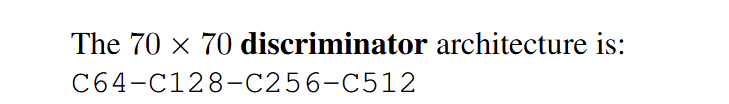
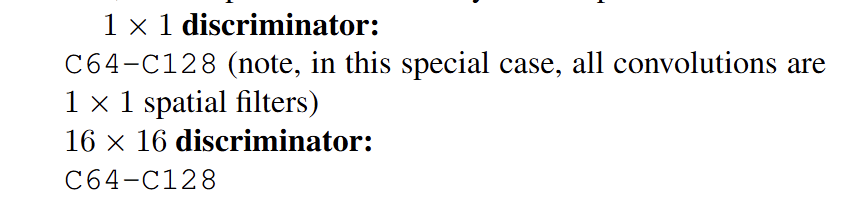
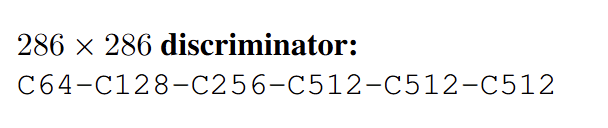

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_nc, output_nc, ndf=64, n_layers=3):
        super(Discriminator, self).__init__()

        # Combined input (real/fake image + conditioned input)
        input_channels = input_nc + output_nc

        layers = [
            nn.Conv2d(input_channels, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        # Intermediate layers: Conv2D → BatchNorm → LeakyReLU
        nf_mult = 1  # Filter multiplier
        nf_mult_prev = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)  # Cap at 8x the number of filters
            layers += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(ndf * nf_mult),
                nn.LeakyReLU(0.2, inplace=True)
            ]

        # Final layer before output: stride=1 to avoid further downsampling
        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        layers += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(ndf * nf_mult),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        # Output layer: Conv2D → Sigmoid
        layers += [
            nn.Conv2d(ndf * nf_mult, 1, kernel_size=4, stride=1, padding=1),
            nn.Sigmoid()  # Binary classification: real/fake
        ]

        # Combine all layers
        self.model = nn.Sequential(*layers)

    def forward(self, input_image, generated_image):
        
        combined_input = torch.cat([input_image, generated_image], dim=1) 
        return self.model(combined_input)



## Loss function for pix2pix model combining:
1. Adversarial Loss (L_cGAN) for the generator to fool the discriminator.
2. L1 Loss (L_L1) for pixel-wise similarity between real and generated images.

*  discriminator_loss: Compute the discriminator loss.
*       
      Args:
          D (nn.Module): Discriminator.
          real_input (Tensor): Input condition (e.g., edges or low-res images).
          real_target (Tensor): Real image (ground truth).
          fake_output (Tensor): Generated image from the generator.

        Returns:
          Tensor: Total discriminator loss.
        
*  generator_loss: Compute the generator loss (L_cGAN + L_L1).

    lambda_L1 (float): Weight for L1 loss term in the total generator loss.

       Args:
          D (nn.Module): Discriminator.
          real_input (Tensor): Input condition.
          real_target (Tensor): Real image (ground truth).
          fake_output (Tensor): Generated image.
   
       Returns:
          dict: Dictionary containing adversarial loss, L1 loss, and total generator loss.
        

In [ ]:
class Pix2PixLoss(nn.Module):

    def __init__(self, lambda_L1=100.0):
        super(Pix2PixLoss, self).__init__()
        self.lambda_L1 = lambda_L1
        self.criterion_GAN = nn.BCEWithLogitsLoss()  # Adversarial loss
        self.criterion_L1 = nn.L1Loss()              # L1 loss

    def discriminator_loss(self, D, real_input, real_target, fake_output):
        valid = torch.ones_like(D(real_input, real_target))  # Real labels = 1
        fake = torch.zeros_like(D(real_input, fake_output))  # Fake labels = 0

        pred_real = D(real_input, real_target)  # Discriminator on real pair
        pred_fake = D(real_input, fake_output.detach())  # Stop gradient for G

        loss_real = self.criterion_GAN(pred_real, valid)  # BCE loss for real data
        loss_fake = self.criterion_GAN(pred_fake, fake)   # BCE loss for fake data
        loss_D = (loss_real + loss_fake) * 0.5  # Total discriminator loss

        return loss_D

    def generator_loss(self, D, real_input, real_target, fake_output):
        # Adversarial Loss (L_cGAN): fool the discriminator
        valid = torch.ones_like(D(real_input, fake_output)) 
        pred_fake = D(real_input, fake_output)
        loss_G_GAN = self.criterion_GAN(pred_fake, valid)

        # L1 Loss (L_L1): minimize pixel-wise difference with ground truth
        loss_G_L1 = self.criterion_L1(fake_output, real_target)

        # Total Generator Loss: L_cGAN + lambda * L_L1
        loss_G = loss_G_GAN + self.lambda_L1 * loss_G_L1

        return {
            "loss_G_GAN": loss_G_GAN,
            "loss_G_L1": loss_G_L1,
            "loss_G_total": loss_G
        }


In [ ]:
def train_pix2pix(generator, discriminator, train_loader, val_loader, criterion, 
                  optimizer_G, optimizer_D, device, output_dir, num_epochs=50, lambda_L1=100.0, resume=True):
    """
    Training loop for the pix2pix model with checkpoint saving and loading.
    """
    # Ensure output directories exist
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(f"{output_dir}/outputs", exist_ok=True)
    os.makedirs(f"{output_dir}/checkpoints", exist_ok=True)  # Directory for per-epoch checkpoints
    
    G_losses, D_losses, val_losses = [], [], []
    best_val_loss = float('inf')  # Track the best validation loss
    start_epoch = 0  # Initialize starting epoch

    # Resume training from checkpoint if specified
    if resume:
        checkpoint = load_checkpoint(f"{output_dir}/checkpoints")
        if checkpoint:
            generator.load_state_dict(checkpoint['generator_state_dict'])
            discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
            optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
            optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
            start_epoch = checkpoint['epoch']
            G_losses = checkpoint['G_losses']
            D_losses = checkpoint['D_losses']
            val_losses = checkpoint['val_losses']
            print(f"Resumed training from epoch {start_epoch+1}")

    for epoch in range(start_epoch, num_epochs):
        epoch_G_loss, epoch_D_loss = 0.0, 0.0

        # Training Phase
        generator.train()
        for real_input, real_target in train_loader:
            real_input, real_target = real_input.to(device), real_target.to(device)

            # --- Train Discriminator ---
            fake_output = generator(real_input)
            loss_D = criterion.discriminator_loss(discriminator, real_input, real_target, fake_output)

            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # --- Train Generator ---
            fake_output = generator(real_input)
            losses_G = criterion.generator_loss(discriminator, real_input, real_target, fake_output)

            optimizer_G.zero_grad()
            losses_G['loss_G_total'].backward()
            optimizer_G.step()

            # Accumulate losses
            epoch_D_loss += loss_D.item()
            epoch_G_loss += losses_G['loss_G_total'].item()

        # Average training losses
        epoch_G_loss /= len(train_loader)
        epoch_D_loss /= len(train_loader)
        G_losses.append(epoch_G_loss)
        D_losses.append(epoch_D_loss)

        # --- Validation Phase ---
        # generator.eval()
        val_loss = 0.0
        # with torch.no_grad():
        #     for real_input, real_target in val_loader:
        #         real_input, real_target = real_input.to(device), real_target.to(device)
        #         fake_output = generator(real_input)
        #         val_loss += criterion.criterion_L1(fake_output, real_target).item()
        # val_loss /= len(val_loader)
        # val_losses.append(val_loss)

        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"D Loss: {epoch_D_loss:.4f} | G Loss: {epoch_G_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save the best generator
        # if val_loss < best_val_loss:
        #     best_val_loss = val_loss
        #     torch.save(generator.state_dict(), f"{output_dir}/best_generator.pth")
        #     print(f"Best generator saved at epoch {epoch+1} with Val Loss: {val_loss:.4f}")

        # Save model checkpoints
        save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, epoch, 
                        G_losses, D_losses, val_losses, output_dir)

        # Save outputs every 10 epochs
        if (epoch + 1) % 10 == 0:
            save_sample_images(generator, val_loader, epoch+1, output_dir, device)
            plot_losses(G_losses, D_losses, val_losses, output_dir)

    # Save final models
    torch.save(generator.state_dict(), f"{output_dir}/final_generator.pth")
    torch.save(discriminator.state_dict(), f"{output_dir}/final_discriminator.pth")
    print("Final models saved successfully!")

    # Plot loss curves
    plot_losses(G_losses, D_losses, val_losses, output_dir)


def save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, epoch, 
                    G_losses, D_losses, val_losses, output_dir):
    """Save generator, discriminator, and optimizers as a checkpoint."""
    checkpoint = {
        'epoch': epoch + 1,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'G_losses': G_losses,
        'D_losses': D_losses,
        'val_losses': val_losses,
    }
    torch.save(checkpoint, f"{output_dir}/checkpoints/latest_checkpoint.pth")
    print(f"Checkpoint saved for epoch {epoch+1}")


def load_checkpoint(checkpoints_dir):
    """Load the latest checkpoint."""
    checkpoint_path = os.path.join(checkpoints_dir, "latest_checkpoint.pth")
    if not os.path.exists(checkpoint_path):
        print("No checkpoint found. Starting training from scratch.")
        return None
    print(f"Loading checkpoint: {checkpoint_path}")
    return torch.load(checkpoint_path)

def save_sample_images(generator, val_loader, epoch, output_dir, device, num_samples=3):
    generator.eval()
    val_iter = iter(val_loader)  # Get an iterator for the validation DataLoader

    for i in range(num_samples):
        try:
            real_input, real_target = next(val_iter)
        except StopIteration:
            break  # If the loader doesn't have enough data, exit the loop

        real_input, real_target = real_input.to(device), real_target.to(device)

        with torch.no_grad():
            fake_output = generator(real_input)

        # Convert tensors to images
        real_input_img = real_input.cpu().numpy()[0].transpose(1, 2, 0)
        real_target_img = real_target.cpu().numpy()[0].transpose(1, 2, 0)
        fake_output_img = fake_output.cpu().numpy()[0].transpose(1, 2, 0)

        # Plot and save the images
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.title("Input Image")
        plt.imshow((real_input_img * 0.5 + 0.5))  # Denormalize
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Generated Image")
        plt.imshow((fake_output_img * 0.5 + 0.5))  # Denormalize
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("Ground Truth")
        plt.imshow((real_target_img * 0.5 + 0.5))  # Denormalize
        plt.axis('off')

        plt.savefig(f"{output_dir}/outputs/img_{i+1}_epoch_{epoch}.png")
        plt.close()

    print(f"Saved {num_samples} sample images for epoch {epoch}.")


def plot_losses(G_losses, D_losses, val_losses, output_dir):
    """Plot generator, discriminator, and validation losses."""
    plt.figure(figsize=(10, 5))
    plt.plot(G_losses, label="Generator Loss")
    plt.title("Generator Losses")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{output_dir}/Generator_losses.png")
    plt.close()
    
    plt.plot(D_losses, label="Discriminator Loss")
    plt.title("Discriminator Losses")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{output_dir}/Discriminator_losses.png")
    plt.close()


In [39]:
# Hyperparameters
num_epochs = 50
lambda_L1 = 100.0
learning_rate = 0.0002
beta = (0.5, 0.999)  #momentum
output_dir = "./results"

# Initialize models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator(input_nc=3, output_nc=3, ngf=64).to(device)
discriminator = Discriminator(input_nc=3, output_nc=3, ndf=64, n_layers=3).to(device)

# Loss function
criterion = Pix2PixLoss(lambda_L1=lambda_L1)

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=beta)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=beta)

# Train the model
train_pix2pix(
    generator,
    discriminator,
    train_loader,
    val_loader,
    criterion,
    optimizer_G,
    optimizer_D,
    device,
    output_dir="./results",
    num_epochs=num_epochs,
    lambda_L1=lambda_L1,
    resume=True
)

Loading checkpoint: ./results/checkpoints/latest_checkpoint.pth


/tmp/ipykernel_23/3692266633.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_path)


Resumed training from epoch 27
Epoch [27/50] | D Loss: 0.5065 | G Loss: 18.1317 | Val Loss: 0.0000
Checkpoint saved for epoch 27
Epoch [28/50] | D Loss: 0.5058 | G Loss: 17.7673 | Val Loss: 0.0000
Checkpoint saved for epoch 28
Epoch [29/50] | D Loss: 0.5050 | G Loss: 17.3640 | Val Loss: 0.0000
Checkpoint saved for epoch 29
Epoch [30/50] | D Loss: 0.5077 | G Loss: 16.9565 | Val Loss: 0.0000
Checkpoint saved for epoch 30
Saved 3 sample images for epoch 30.
Epoch [31/50] | D Loss: 0.5069 | G Loss: 16.4808 | Val Loss: 0.0000
Checkpoint saved for epoch 31
Epoch [32/50] | D Loss: 0.5084 | G Loss: 16.0923 | Val Loss: 0.0000
Checkpoint saved for epoch 32
Epoch [33/50] | D Loss: 0.5068 | G Loss: 15.6251 | Val Loss: 0.0000
Checkpoint saved for epoch 33
Epoch [34/50] | D Loss: 0.5045 | G Loss: 15.2444 | Val Loss: 0.0000
Checkpoint saved for epoch 34
Epoch [35/50] | D Loss: 0.5056 | G Loss: 14.8958 | Val Loss: 0.0000
Checkpoint saved for epoch 35
Epoch [36/50] | D Loss: 0.5039 | G Loss: 14.4876 | 

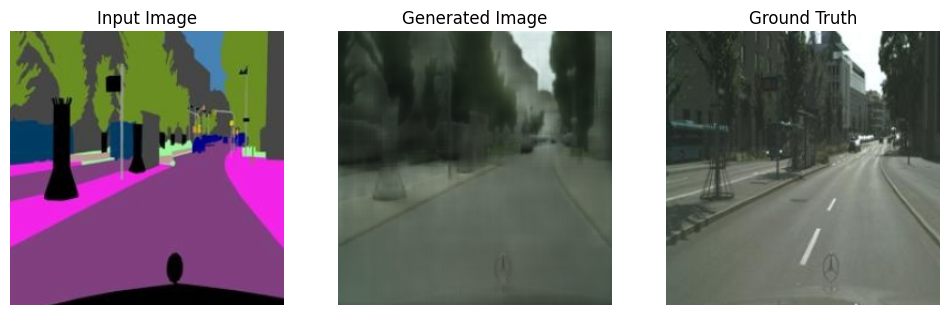

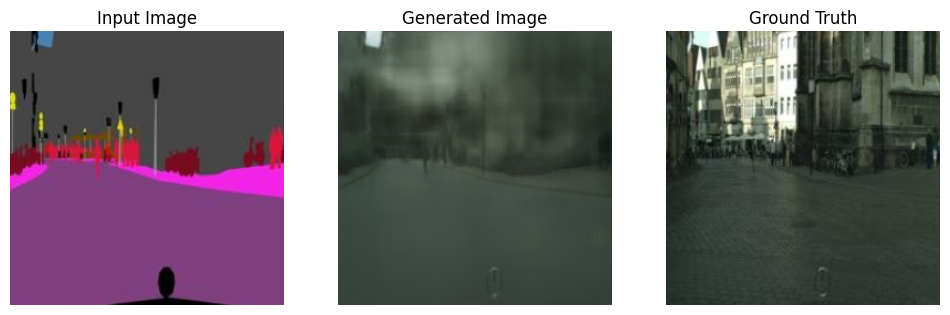

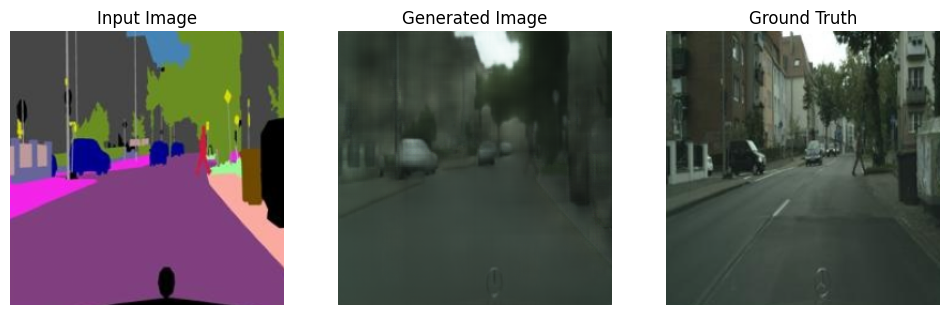

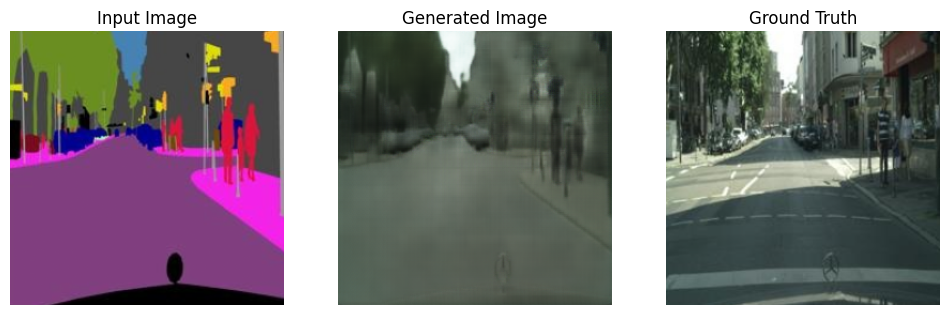

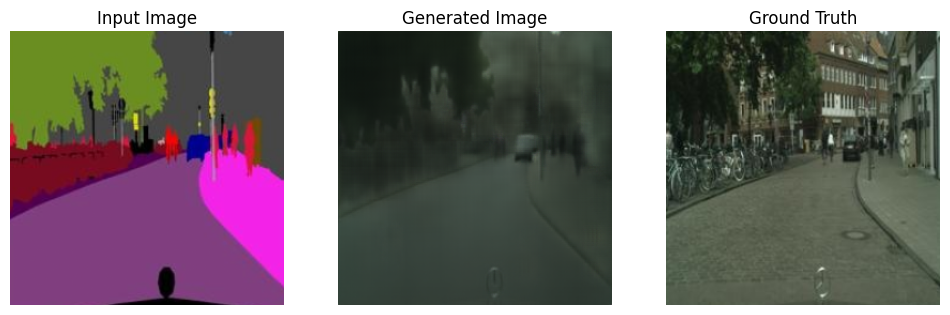

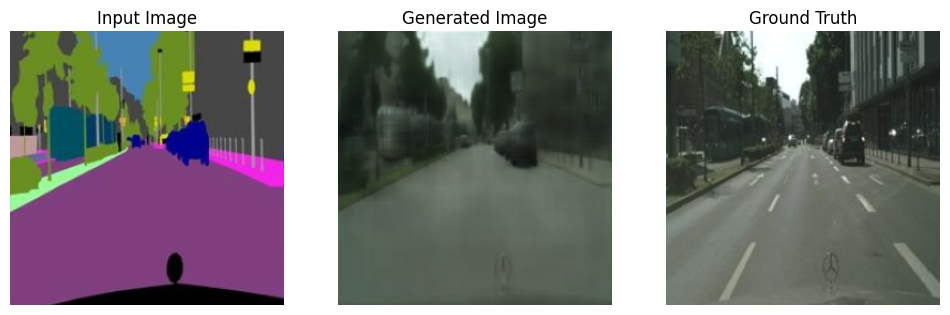

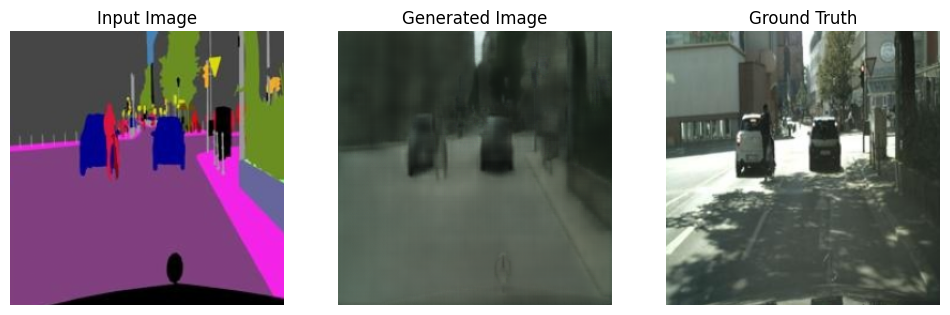

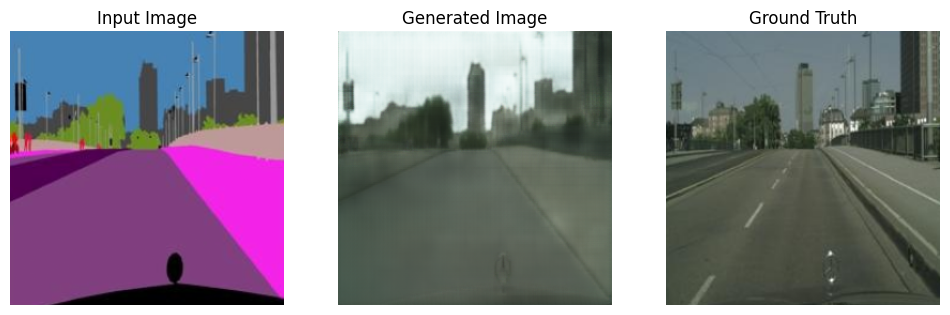

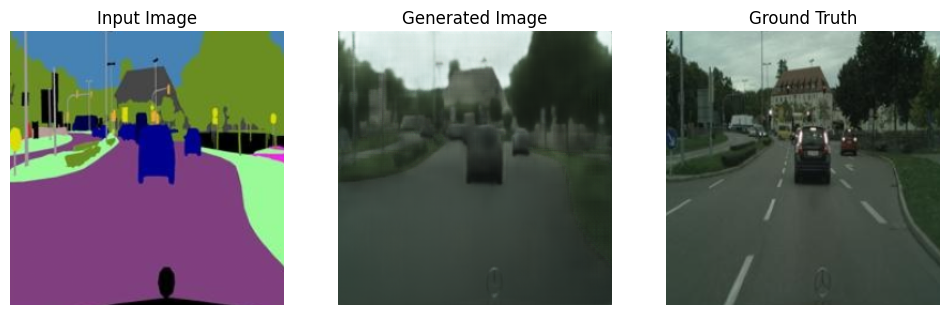

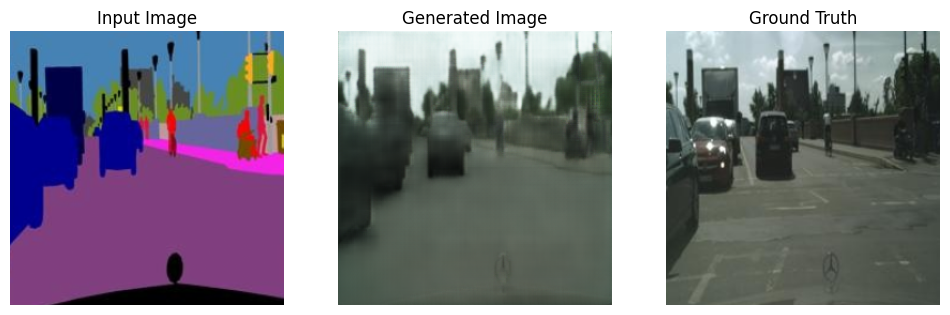

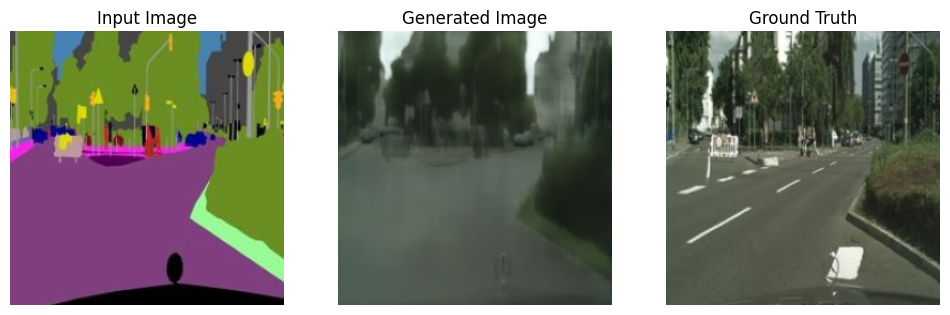

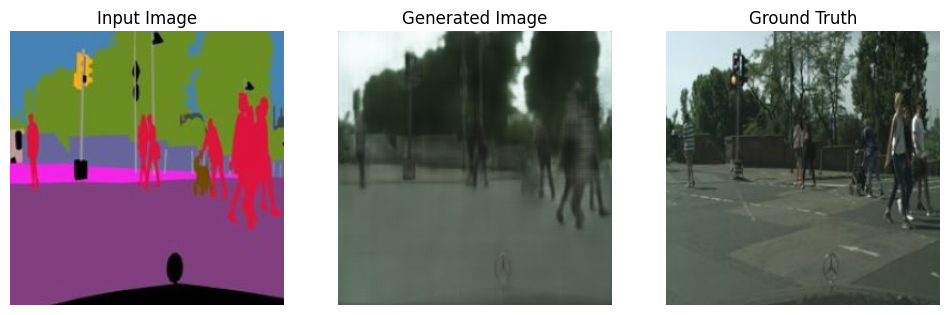

In [ ]:
generator.eval()
val_iter = iter(val_loader)  # Get an iterator for the validation DataLoader

for i, (real_input, real_target) in enumerate(val_iter):
    if i >> 10:
        break
    real_input, real_target = real_input.to(device), real_target.to(device)

    with torch.no_grad():
        fake_output = generator(real_input)

    # Convert tensors to images (denormalizing them to [0, 1])
    real_input_img = real_input.cpu().numpy()[0].transpose(1, 2, 0)
    real_target_img = real_target.cpu().numpy()[0].transpose(1, 2, 0)
    fake_output_img = fake_output.cpu().numpy()[0].transpose(1, 2, 0)

    # Plot and show the images
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow((real_input_img * 0.5 + 0.5))  # Denormalize
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Generated Image")
    plt.imshow((fake_output_img * 0.5 + 0.5))  # Denormalize
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Ground Truth")
    plt.imshow((real_target_img * 0.5 + 0.5))  # Denormalize
    plt.axis('off')

    plt.show()  # Display the images instead of saving them


In [ ]:
image_dir = os.path.join(output_dir, "outputs")
    
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png') and "epoch" in f]

# Sort the image files to ensure consistent order
image_files.sort()

if not image_files:
    print("No images found to display.")

for img_file in image_files:
    img_path = os.path.join(image_dir, img_file)
    img = Image.open(img_path)

    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(img_file)
    plt.axis('off')
    plt.show()


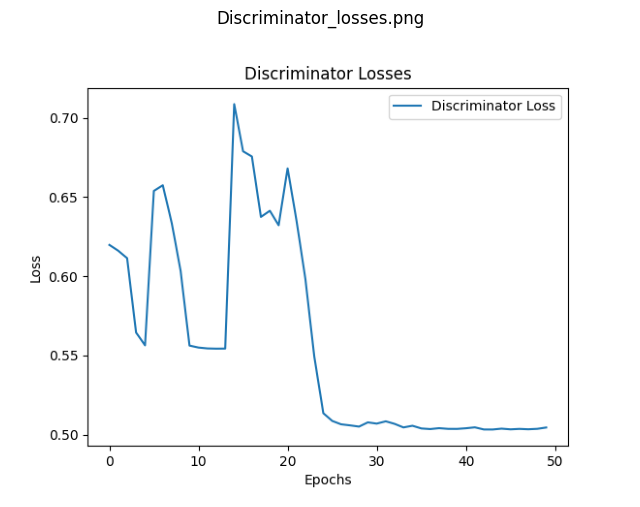

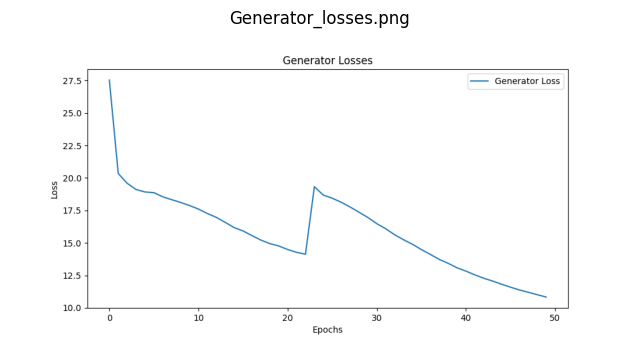

In [52]:
image_dir =['/kaggle/working/results/Discriminator_losses.png','/kaggle/working/results/Generator_losses.png']
for image_path in image_dir:    
    img = Image.open(image_path)
    
    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(image_path.split('/')[-1])  # Display the filename as the title
    plt.axis('off')
    plt.show()
